In [1]:
import numpy as np
import skimage
import torch
import torchvision
import matplotlib.pyplot as plt
import torchxrayvision as xrv
import cv2

/home/ca_uop_muoi/Applications/graduate_thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Overview with torchxrayvision for anatomy segmentation

In [2]:
model = xrv.baseline_models.chestx_det.PSPNet()

In [3]:
img = cv2.imread("/home/ca_uop_muoi/Applications/graduate_thesis/notebook/anomaly_detection/cxr_sample.png", cv2.IMREAD_GRAYSCALE)
img = xrv.datasets.normalize(img, 255)

In [4]:
img.min(), img.max()

(np.float32(-1024.0), np.float32(1024.0))

In [5]:
if len(img.shape) > 2:
    img = img.mean(2)

img = img[None, ...] 

transform = torchvision.transforms.Compose([
    xrv.datasets.XRayCenterCrop(),
])

img = transform(img)
img = torch.from_numpy(img)

In [6]:
with torch.no_grad():
    pred = model(img)

In [7]:
pred.shape

torch.Size([1, 14, 512, 512])

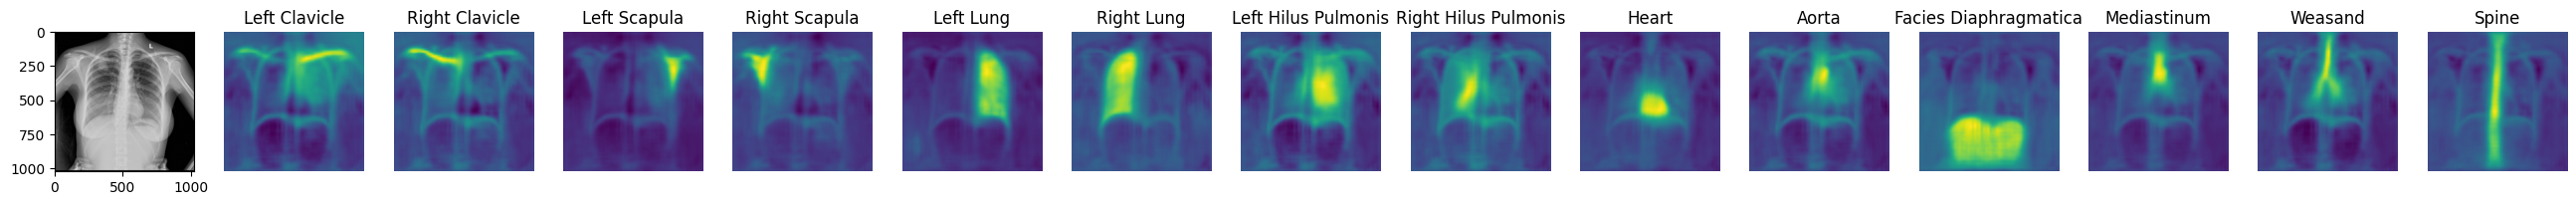

In [8]:
plt.figure(figsize = (26,5))
plt.subplot(1, len(model.targets) + 1, 1)
plt.imshow(img[0], cmap='gray')
for i in range(len(model.targets)):
    plt.subplot(1, len(model.targets) + 1, i+2)
    plt.imshow(pred[0, i])
    plt.title(model.targets[i])
    plt.axis('off')
plt.tight_layout()

In [9]:
pred = 1 / (1 + np.exp(-pred))  # sigmoid
pred[pred < 0.5] = 0
pred[pred > 0.5] = 1

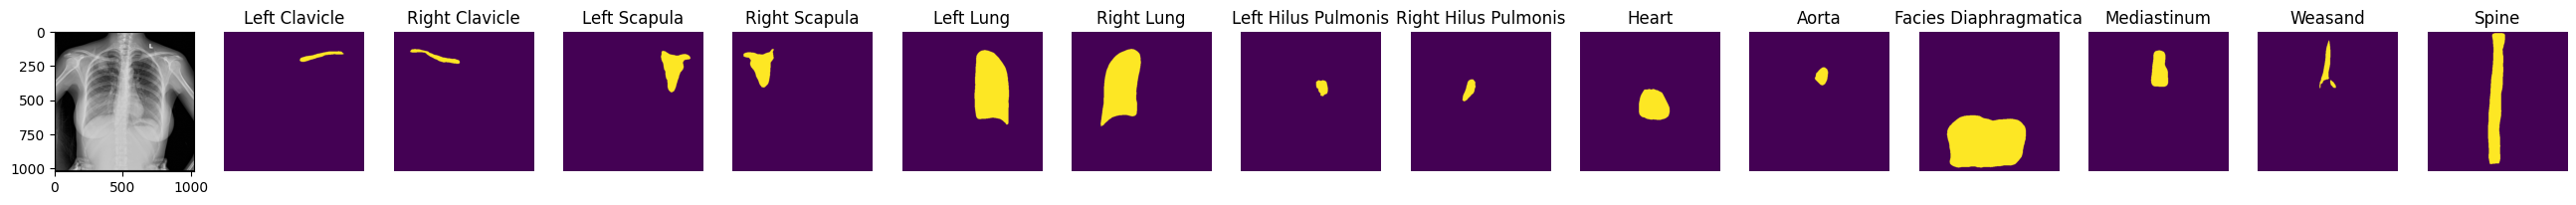

In [10]:
plt.figure(figsize = (26,5))
plt.subplot(1, len(model.targets) + 1, 1)
plt.imshow(img[0], cmap='gray')
for i in range(len(model.targets)):
    plt.subplot(1, len(model.targets) + 1, i+2)
    plt.imshow(pred[0, i])
    plt.title(model.targets[i])
    plt.axis('off')
plt.tight_layout()

### Restore original size for anatomy masks (512 to 1024)

In [11]:
img.shape

torch.Size([1, 1024, 1024])

In [12]:
import torch.nn.functional as F
import copy

# Interpolate image to 512x512 for segmentation model
img_for_seg = torch.nn.functional.interpolate(
    img.clone().unsqueeze(0), # add batch dimension
    size=(512, 512), 
    mode='bilinear', # use bilinear interpolation for resizing
    align_corners=False
)

img_for_seg.shape

torch.Size([1, 1, 512, 512])

In [13]:
with torch.no_grad():
    pred_512 = model(img_for_seg) # shape: [1, C, 512, 512]
    
pred_512.shape

torch.Size([1, 14, 512, 512])

In [14]:
pred_1024_soft = F.interpolate(
    pred_512, 
    size=(img.shape[-2], img.shape[-1]), # (1024, 1024)
    mode='bilinear', 
    align_corners=False
)

pred_1024_soft.shape

torch.Size([1, 14, 1024, 1024])

In [15]:
pred_1024_soft = 1 / (1 + torch.exp(-pred_1024_soft))

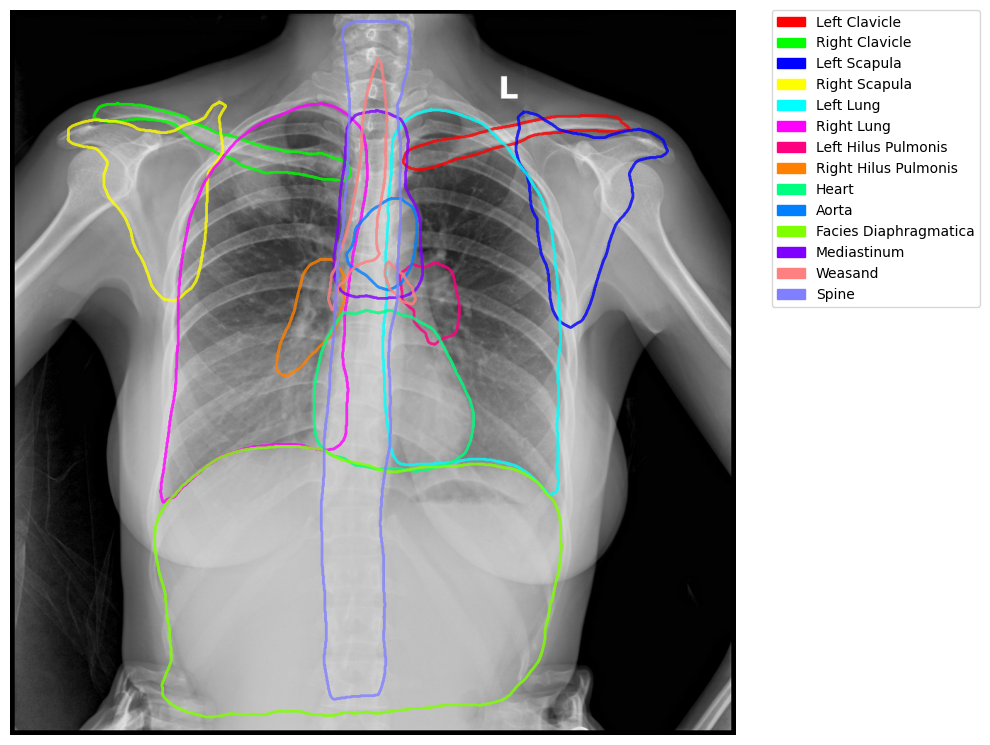

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


img_np = img.squeeze(0).numpy() # -> (1024, 1024)
if torch.is_tensor(img_np):
    img_np = img_np.cpu().numpy()

# Normalize ảnh gốc về 0-255 và chuyển sang 3 kênh (RGB) để vẽ màu đè lên
img_vis = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
img_vis = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2RGB)

# Lấy soft predictions 1024x1024
# pred_1024_soft đã được Sigmoid, shape: (1, 14, 1024, 1024)
preds_np = pred_1024_soft.squeeze(0).cpu().numpy() # -> (14, 1024, 1024)

# Các class mục tiêu từ model
targets = model.targets

# # Tạo màu ngẫu nhiên nhưng dễ phân biệt cho 14 lớp (BGR format cho OpenCV)
# np.random.seed(50)
# colors = [tuple(np.random.randint(50, 255, 3).tolist()) for _ in range(len(targets))]

colors = [
    (0, 0, 255),       # Đỏ tươi
    (0, 255, 0),       # Xanh lá sáng
    (255, 0, 0),       # Xanh dương tươi
    (0, 255, 255),     # Vàng sáng
    (255, 255, 0),     # Cyan
    (255, 0, 255),     # Hồng fuchsia
    (128, 0, 255),     # Tím sáng
    (0, 128, 255),     # Cam sáng
    (128, 255, 0),     # Xanh lá mạ
    (255, 128, 0),     # Cam đậm
    (0, 255, 128),     # Ngọc lục bảo
    (255, 0, 128),     # Hồng neon
    (128, 128, 255),   # Xanh lam nhạt
    (255, 128, 128)    # Hồng pastel
]

colors_rgb = [(r/255, g/255, b/255) for (b, g, r) in colors] 


plt.figure(figsize=(10, 10))
ax = plt.gca()

# Hiển thị ảnh gốc trước
ax.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))

legend_patches = []

# Duyệt qua từng vùng giải phẫu
for i, target_name in enumerate(targets):
    # Thresholding mask
    mask_bin = (preds_np[i] > 0.5).astype(np.uint8)
    
    if mask_bin.sum() == 0:
        continue # Không tìm thấy vùng này
        
    # Tìm viền contour
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Vẽ viền lên ảnh (vẽ trực tiếp nhưng dùng ax plot cho đẹp trên plt)
    color_rgb = colors_rgb[i] # RGB float for matplotlib
    
    for contour in contours:
        # Contour có dạng (N, 1, 2)
        contour = contour.squeeze(1)
        if len(contour) < 3: 
            continue
        
        # Đóng vòng contour
        poly = np.vstack((contour, contour[0]))
        
        # Vẽ contour
        ax.plot(poly[:, 0], poly[:, 1], color=color_rgb, linewidth=2, alpha=0.8)
        
    legend_patches.append(mpatches.Patch(color=color_rgb, label=target_name))

ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.axis('off')
# plt.title("Anatomical Segmentations Overlaid on Original Image (1024x1024)", fontsize=16)
plt.tight_layout()
plt.show()

### Distributing image patches to corresponding anatomies

In [17]:
targets

['Left Clavicle',
 'Right Clavicle',
 'Left Scapula',
 'Right Scapula',
 'Left Lung',
 'Right Lung',
 'Left Hilus Pulmonis',
 'Right Hilus Pulmonis',
 'Heart',
 'Aorta',
 'Facies Diaphragmatica',
 'Mediastinum',
 'Weasand',
 'Spine']